In [ ]:
import requests, re

vocab_size_sos = 10
texto = f"""O projeto Agents4Good realizou uma preparação cuidadosa para garantir que o evento resultasse em soluções concretas. Foram promovidas três oficinas e um seminário sobre tecnologias relacionadas ao evento, abertos não apenas ao alunado da UASC/UFCG mas também ao público externo à UFCG. Além disso, integrantes do projeto — previamente capacitados nessas tecnologias — foram distribuídos entre as equipes participantes do Hackathon. As equipes tiveram o apoio de mentores, que detinham conhecimento sobre o domínio do problema, seus desafios, restrições e dados."""

frases = re.split(r'[.!?]', texto)
pattern = r'<[^>]+>|\b\w+\b'

sentencas = [re.findall(pattern, frase.lower()) for frase in frases if frase.strip()]

texto_unico = " ".join(word for frase in sentencas for word in frase)
print(texto_unico)

In [ ]:
import torch
from torch.utils.data import Dataset

class LanguageDataset(Dataset):
    def __init__(self, tokens, word_to_ix):
        self.data = []
        self.word_to_ix = word_to_ix

        for i in range(len(tokens) - 1):
            input_word = tokens[i]
            target_word = tokens[i + 1]
            if input_word in word_to_ix and target_word in word_to_ix:
                input_emb = word_to_ix[input_word]["emb"]
                target_emb = word_to_ix[target_word]["emb"]
                self.data.append((input_emb, target_emb))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input_emb, target_emb = self.data[idx]
        return (
            torch.tensor(input_emb, dtype=torch.float32),
            torch.tensor(target_emb, dtype=torch.float32)
        )

    def get_all(self):
        return self.data

In [ ]:
tokens = texto_unico.split()

vocab = sorted(set(tokens))
vocab_size = len(vocab)

word_to_ix = {}
for i, w in enumerate(vocab):
    emb = [0] * vocab_size
    emb[i] = 1
    word_to_ix[w] = {
        "idx": i,
        "emb": emb
    }

tokens = [w for w in tokens if w in word_to_ix]

dataset = LanguageDataset(tokens=tokens, word_to_ix=word_to_ix)
for context_tensor, target_tensor in dataset:
    print(context_tensor.shape, target_tensor.shape)

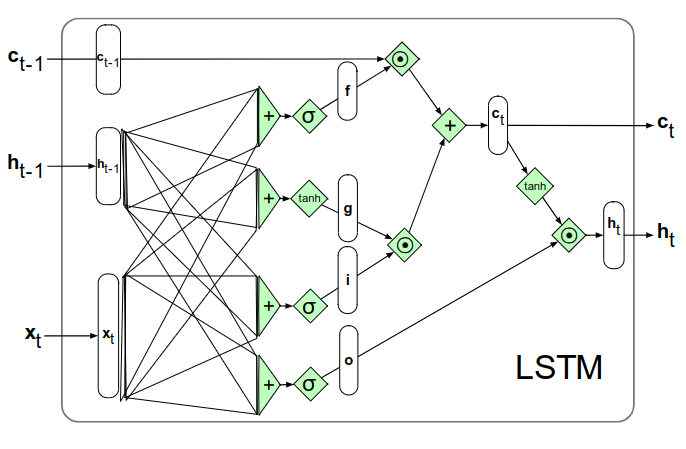

In [ ]:
import torch.nn as nn
import torch.optim as optim

class LSTM(nn.Module):
    def __init__(self, embedding_dim):
        super(LSTM, self).__init__()

        self.embedding_dim = embedding_dim

        # Esquecer
        self.ht_1_forget = nn.Linear(embedding_dim, embedding_dim)
        self.xt_forget = nn.Linear(embedding_dim, embedding_dim)

        # Novas informações candidatas
        self.ht_1_candidate = nn.Linear(embedding_dim, embedding_dim)
        self.xt_candidate = nn.Linear(embedding_dim, embedding_dim)

        # Decisor do que será lembrado
        self.ht_1_inputgate = nn.Linear(embedding_dim, embedding_dim)
        self.xt_inputgate = nn.Linear(embedding_dim, embedding_dim)

        # Decide o que será esquecido
        self.xt_output_gate = nn.Linear(embedding_dim, embedding_dim)
        self.h1_1_output_gate = nn.Linear(embedding_dim, embedding_dim)

        self.out_layer = nn.Linear(embedding_dim, embedding_dim)


    def forward(self, xt, ht_1, ct_1):
        forget = nn.functional.sigmoid(
            self.ht_1_forget(ht_1) + self.xt_forget(xt)
        )
        candid = nn.functional.tanh(
            self.ht_1_candidate(ht_1) + self.xt_candidate(xt)
        )
        input = nn.functional.sigmoid(
            self.ht_1_inputgate(ht_1) + self.xt_inputgate(xt)
        )
        o = nn.functional.sigmoid(
            self.h1_1_output_gate(ht_1) + self.xt_output_gate(xt)
        )

        hadamart_candidate_input = torch.mul(candid, input)

        c_t = torch.mul(forget, ct_1) + torch.mul(candid, input)
        h_t = torch.mul(o, nn.functional.tanh(c_t))

        return h_t, c_t


    def train_model(self, dataset, epochs=10, lr=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        loss_fn = nn.BCEWithLogitsLoss()

        for epoch in range(epochs):
            total_loss = 0.0
            for inputs, label in dataset:
                ht = torch.zeros(self.embedding_dim)
                ct = torch.zeros(self.embedding_dim)

                xt = inputs
                ht, ct = self.forward(xt, ht, ct)

                output = self.out_layer(ht).squeeze()
                loss = loss_fn(output, label)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

In [ ]:
embedding_dim = len(vocab)
model = LSTM(embedding_dim=embedding_dim)
model.train_model(dataset=dataset, epochs=100, lr=0.0001)

In [ ]:
def gerar_frase(frase_inicial, num_palavras=10):
    palavras = frase_inicial.lower().split()
    ht = torch.zeros(model.embedding_dim)
    ct = torch.zeros(model.embedding_dim)

    for palavra in palavras:
        if palavra not in word_to_ix:
            print(f"\n'{palavra}' não está no vocabulário")
            return
        entrada = torch.tensor(word_to_ix[palavra]["emb"], dtype=torch.float32)
        with torch.no_grad():
            ht, ct = model(entrada, ht, ct)

    palavra_atual = palavras[-1]
    print(f"\n{frase_inicial}", end=' ')

    for _ in range(num_palavras):
        entrada = torch.tensor(word_to_ix[palavra_atual]["emb"], dtype=torch.float32)
        with torch.no_grad():
            ht, ct = model(entrada, ht, ct)
            saida = model.out_layer(ht)
            probs = F.softmax(saida, dim=0)
            idx_next = torch.multinomial(probs, 1).item()
            proxima_palavra = vocab[idx_next]

            print(proxima_palavra, end=' ')
            palavra_atual = proxima_palavra

In [ ]:
gerar_frase("o projeto agents4good", num_palavras=60)